# exp002 CV-LB 乖離・原因深掘り分析

## 目的
- CV過大（0.72）とLB低下（0.50）の原因を特定
- 分割設計・前処理・補助損失・ターゲット構成の4観点で分析


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings("ignore")

# 設定
BASE_DIR = Path("/Users/goyashuto/develop/github.com/508shuto/kaggle-csiro")
OUTPUT_DIR = BASE_DIR / "output/exp002"
INPUT_DIR = BASE_DIR / "input"

# 可視化設定
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [2]:
# データ読み込み
df_train = pd.read_csv(OUTPUT_DIR / "preprocessed_train.csv")
df_oofs = pd.read_csv(OUTPUT_DIR / "oofs.csv")
df_results = pd.read_json(OUTPUT_DIR / "results.json", typ="series")

print(f"Train samples: {len(df_train)}")
print(f"OOF predictions: {len(df_oofs)}")
print(f"CV score: {df_results['mean_score']:.4f} ± {df_results['std_score']:.4f}")
print(f"\nFold scores: {df_results['fold_scores']}")

# 基本的な統計
print("\nSpecies分布:")
print(df_train["species"].value_counts())
print("\nState分布:")
print(df_train["state"].value_counts())
print("\nSampling_Date分布:")
print(df_train["sampling_date"].value_counts().head(10))

Train samples: 357
OOF predictions: 357
CV score: 0.7239 ± 0.0426

Fold scores: [0.7694759964942931, 0.7747420191764831, 0.6953666388988491, 0.715199935436248, 0.6646633386611931]

Species分布:
species
Ryegrass_Clover                                                98
Ryegrass                                                       62
Phalaris_Clover                                                42
Clover                                                         41
Fescue                                                         28
Lucerne                                                        22
Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed    11
Fescue_CrumbWeed                                               10
WhiteClover                                                    10
Phalaris_Ryegrass_Clover                                        8
Phalaris                                                        8
Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass                 7
Subclove

## 1) 分割リークの定量診断


In [3]:
# 現行foldでのgroup leakage ratioを算出
# group = Sampling_Date + '_' + State

df_train["group"] = df_train["sampling_date"] + "_" + df_train["state"]

leakage_stats = []
for fold in range(5):
    train_fold = df_train[df_train["fold"] != fold]
    valid_fold = df_train[df_train["fold"] == fold]

    train_groups = set(train_fold["group"])
    valid_groups = set(valid_fold["group"])

    # グループが複数foldに跨っている数
    overlapping_groups = train_groups & valid_groups

    # サンプル数での重複
    valid_samples_in_overlapping = valid_fold[
        valid_fold["group"].isin(list(overlapping_groups))
    ]

    leakage_stats.append(
        {
            "fold": fold,
            "valid_samples": len(valid_fold),
            "valid_groups": len(valid_groups),
            "overlapping_groups": len(overlapping_groups),
            "overlapping_samples": len(valid_samples_in_overlapping),
            "leakage_ratio_groups": len(overlapping_groups) / len(valid_groups)
            if len(valid_groups) > 0
            else 0,
            "leakage_ratio_samples": len(valid_samples_in_overlapping) / len(valid_fold)
            if len(valid_fold) > 0
            else 0,
        }
    )

df_leakage = pd.DataFrame(leakage_stats)
print("現行fold（StratifiedKFold by species）でのgroup leakage:")
print(df_leakage)
print(f"\n平均 leakage ratio (groups): {df_leakage['leakage_ratio_groups'].mean():.2%}")
print(f"平均 leakage ratio (samples): {df_leakage['leakage_ratio_samples'].mean():.2%}")

現行fold（StratifiedKFold by species）でのgroup leakage:
   fold  valid_samples  valid_groups  overlapping_groups  overlapping_samples  \
0     0             72            26                  26                   72   
1     1             72            27                  27                   72   
2     2             71            29                  28                   70   
3     3             71            25                  25                   71   
4     4             71            28                  28                   71   

   leakage_ratio_groups  leakage_ratio_samples  
0              1.000000               1.000000  
1              1.000000               1.000000  
2              0.965517               0.985915  
3              1.000000               1.000000  
4              1.000000               1.000000  

平均 leakage ratio (groups): 99.31%
平均 leakage ratio (samples): 99.72%


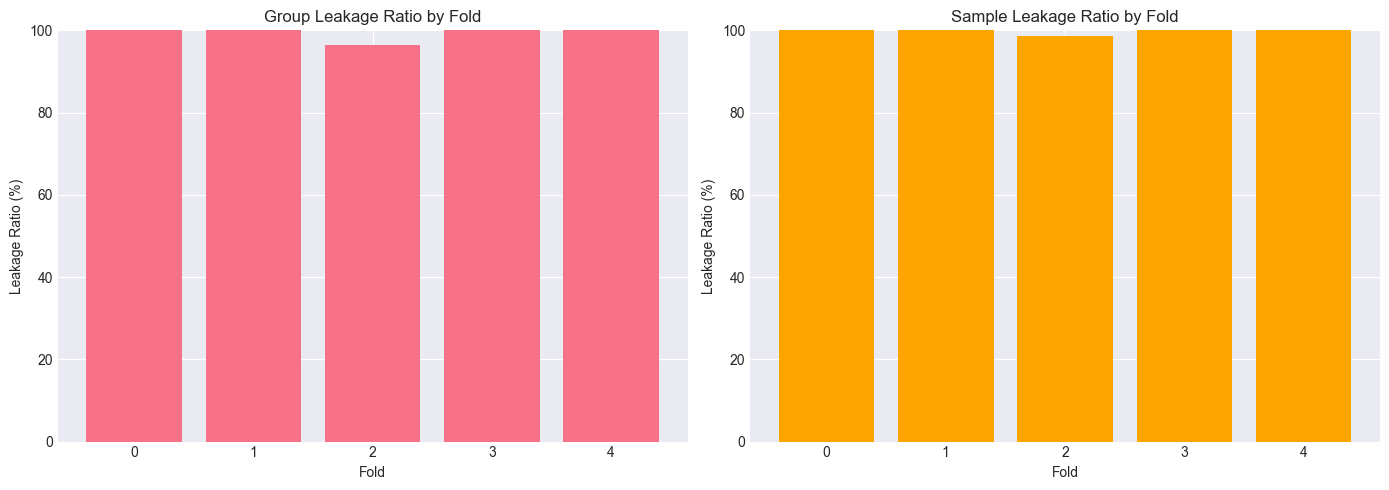

In [4]:
# 可視化: fold別のgroup leakage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df_leakage["fold"], df_leakage["leakage_ratio_groups"] * 100)
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Leakage Ratio (%)")
axes[0].set_title("Group Leakage Ratio by Fold")
axes[0].set_ylim(0, 100)

axes[1].bar(
    df_leakage["fold"], df_leakage["leakage_ratio_samples"] * 100, color="orange"
)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Leakage Ratio (%)")
axes[1].set_title("Sample Leakage Ratio by Fold")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [5]:
# 代替分割方式の比較（GroupKFold by Species）
df_alt = df_train.copy()
df_alt["fold_alt"] = -1

# GroupKFold by Species
gkf = GroupKFold(n_splits=5)
for fold, (_, val_idx) in enumerate(gkf.split(df_alt, groups=df_alt["species"])):
    df_alt.loc[val_idx, "fold_alt"] = fold

# 新しい分割でのgroup leakage
leakage_stats_alt = []
for fold in range(5):
    train_fold = df_alt[df_alt["fold_alt"] != fold]
    valid_fold = df_alt[df_alt["fold_alt"] == fold]

    train_groups = set(train_fold["group"])
    valid_groups = set(valid_fold["group"])
    overlapping_groups = train_groups & valid_groups

    valid_samples_in_overlapping = valid_fold[
        valid_fold["group"].isin(list(overlapping_groups))
    ]

    leakage_stats_alt.append(
        {
            "fold": fold,
            "valid_samples": len(valid_fold),
            "valid_groups": len(valid_groups),
            "overlapping_groups": len(overlapping_groups),
            "overlapping_samples": len(valid_samples_in_overlapping),
            "leakage_ratio_groups": len(overlapping_groups) / len(valid_groups)
            if len(valid_groups) > 0
            else 0,
            "leakage_ratio_samples": len(valid_samples_in_overlapping) / len(valid_fold)
            if len(valid_fold) > 0
            else 0,
        }
    )

df_leakage_alt = pd.DataFrame(leakage_stats_alt)
print("GroupKFold by Speciesでのgroup leakage:")
print(df_leakage_alt)
print(
    f"\n平均 leakage ratio (groups): {df_leakage_alt['leakage_ratio_groups'].mean():.2%}"
)
print(
    f"平均 leakage ratio (samples): {df_leakage_alt['leakage_ratio_samples'].mean():.2%}"
)

GroupKFold by Speciesでのgroup leakage:
   fold  valid_samples  valid_groups  overlapping_groups  overlapping_samples  \
0     0             98             9                   3                   26   
1     1             64             6                   3                   23   
2     2             67             9                   2                   14   
3     3             65             7                   4                   34   
4     4             63             6                   1                    3   

   leakage_ratio_groups  leakage_ratio_samples  
0              0.333333               0.265306  
1              0.500000               0.359375  
2              0.222222               0.208955  
3              0.571429               0.523077  
4              0.166667               0.047619  

平均 leakage ratio (groups): 35.87%
平均 leakage ratio (samples): 28.09%


## 2) OOFスコアの内訳検証


In [6]:
# ターゲット別R2スコアをfold別に算出
WEIGHTS = [0.1, 0.1, 0.1, 0.2, 0.5]
TARGET_NAMES = [
    "clover_target",
    "dead_target",
    "green_target",
    "gdm_target",
    "total_target",
]

target_scores = []
for fold in range(5):
    valid_df = df_train[df_train["fold"] == fold]
    valid_oofs = df_oofs.iloc[valid_df.index]

    fold_scores = []
    for i, target in enumerate(TARGET_NAMES):
        r2 = r2_score(valid_df[target], valid_oofs[target])
        fold_scores.append(r2)
        target_scores.append(
            {
                "fold": fold,
                "target": target,
                "r2": r2,
                "weight": WEIGHTS[i],
                "weighted_r2": WEIGHTS[i] * r2,
            }
        )

df_target_scores = pd.DataFrame(target_scores)
print("ターゲット別R2スコア（fold別）:")
print(df_target_scores.pivot(index="fold", columns="target", values="r2"))
print("\n重み付き寄与:")
print(df_target_scores.pivot(index="fold", columns="target", values="weighted_r2"))

ターゲット別R2スコア（fold別）:
target  clover_target  dead_target  gdm_target  green_target  total_target
fold                                                                      
0            0.900779     0.560171    0.835746      0.812973      0.749869
1            0.842484     0.572464    0.856061      0.912145      0.741641
2            0.687154     0.559287    0.754515      0.779401      0.683759
3            0.783314     0.490997    0.802360      0.816218      0.691350
4            0.548595     0.565438    0.653772      0.726877      0.699636

重み付き寄与:
target  clover_target  dead_target  gdm_target  green_target  total_target
fold                                                                      
0            0.090078     0.056017    0.167149      0.081297      0.374934
1            0.084248     0.057246    0.171212      0.091215      0.370821
2            0.068715     0.055929    0.150903      0.077940      0.341879
3            0.078331     0.049100    0.160472      0.081622      0.345

In [7]:
# Total除外時のWeighted R2（重み再正規化）
WEIGHTS_WITHOUT_TOTAL = [0.1, 0.1, 0.1, 0.2]  # Clover, Dead, Green, GDM
WEIGHTS_NORMALIZED = np.array(WEIGHTS_WITHOUT_TOTAL) / np.sum(WEIGHTS_WITHOUT_TOTAL)
TARGETS_WITHOUT_TOTAL = ["clover_target", "dead_target", "green_target", "gdm_target"]

total_excluded_scores = []
for fold in range(5):
    valid_df = df_train[df_train["fold"] == fold]
    valid_oofs = df_oofs.iloc[valid_df.index]

    weighted_r2 = 0.0
    for i, target in enumerate(TARGETS_WITHOUT_TOTAL):
        r2 = r2_score(valid_df[target], valid_oofs[target])
        weighted_r2 += WEIGHTS_NORMALIZED[i] * r2

    total_excluded_scores.append(
        {
            "fold": fold,
            "weighted_r2_without_total": weighted_r2,
        }
    )

df_total_excluded = pd.DataFrame(total_excluded_scores)
print("Total除外時のWeighted R2（重み再正規化）:")
print(df_total_excluded)
print(f"\n平均: {df_total_excluded['weighted_r2_without_total'].mean():.4f}")
print(f"\n現行CV（Total含む）: {df_results['mean_score']:.4f}")
print(f"Total除外CV: {df_total_excluded['weighted_r2_without_total'].mean():.4f}")
print(
    f"差分: {df_results['mean_score'] - df_total_excluded['weighted_r2_without_total'].mean():.4f}"
)

Total除外時のWeighted R2（重み再正規化）:
   fold  weighted_r2_without_total
0     0                   0.789083
1     1                   0.807843
2     2                   0.706975
3     3                   0.739050
4     4                   0.629691

平均: 0.7345

現行CV（Total含む）: 0.7239
Total除外CV: 0.7345
差分: -0.0106


## 3) 前処理キャッシュの整合性確認


In [8]:
# image_pathの整合性確認
df_train["image_path_exp"] = df_train["image_path"].apply(
    lambda x: "exp000"
    if "exp000" in str(x)
    else ("exp002" if "exp002" in str(x) else "other")
)
print("image_pathの分布:")
print(df_train["image_path_exp"].value_counts())
print(f"\n混在率: {df_train['image_path_exp'].value_counts(normalize=True)}")

# ランダムサンプルでshape確認

sample_paths = df_train["image_path"].sample(min(5, len(df_train)), random_state=42)
print("\nランダムサンプルのshape確認:")
for path in sample_paths:
    try:
        img = np.load(BASE_DIR / path)
        print(
            f"{path}: shape={img.shape}, dtype={img.dtype}, mean={img.mean():.2f}, std={img.std():.2f}"
        )
    except Exception as e:
        print(f"{path}: Error - {e}")

image_pathの分布:
image_path_exp
exp000    357
Name: count, dtype: int64

混在率: image_path_exp
exp000    1.0
Name: proportion, dtype: float64

ランダムサンプルのshape確認:
output/exp000/train/ID307060225.npy: shape=(512, 512, 3), dtype=float32, mean=97.90, std=62.40
output/exp000/train/ID1199150612.npy: shape=(512, 512, 3), dtype=float32, mean=120.63, std=51.59
output/exp000/train/ID668330410.npy: shape=(512, 512, 3), dtype=float32, mean=103.45, std=58.70
output/exp000/train/ID697718693.npy: shape=(512, 512, 3), dtype=float32, mean=84.97, std=62.68
output/exp000/train/ID1277756619.npy: shape=(512, 512, 3), dtype=float32, mean=123.28, std=46.03


## 4) 補助損失(aux)の影響切り分け


In [9]:
# OOF残差とtabular特徴の相関
from scipy.stats import pearsonr, spearmanr

# 残差を計算
for target in TARGET_NAMES:
    df_train[f"{target}_residual"] = df_train[target] - df_oofs[target]

# 相関分析
correlations = []
for target in TARGET_NAMES:
    for feature in ["pre_gshh_ndvi", "height_ave_cm"]:
        pearson_corr, pearson_p = pearsonr(
            df_train[f"{target}_residual"], df_train[feature]
        )
        spearman_corr, spearman_p = spearmanr(
            df_train[f"{target}_residual"], df_train[feature]
        )

        correlations.append(
            {
                "target": target,
                "feature": feature,
                "pearson_corr": pearson_corr,
                "pearson_p": pearson_p,
                "spearman_corr": spearman_corr,
                "spearman_p": spearman_p,
            }
        )

df_correlations = pd.DataFrame(correlations)
print("OOF残差とtabular特徴の相関:")
print(
    df_correlations.pivot_table(
        index="target", columns="feature", values=["pearson_corr", "spearman_corr"]
    )
)

significant = df_correlations[
    (df_correlations["pearson_p"] < 0.05) | (df_correlations["spearman_p"] < 0.05)
]
if len(significant) > 0:
    print("\n有意な相関（p < 0.05）:")
    print(
        significant[
            [
                "target",
                "feature",
                "pearson_corr",
                "pearson_p",
                "spearman_corr",
                "spearman_p",
            ]
        ]
    )
else:
    print("\n有意な相関は見つかりませんでした（p >= 0.05）")

OOF残差とtabular特徴の相関:
               pearson_corr               spearman_corr              
feature       height_ave_cm pre_gshh_ndvi height_ave_cm pre_gshh_ndvi
target                                                               
clover_target     -0.043873      0.053922     -0.016019      0.048147
dead_target        0.059635      0.052318      0.060673      0.086404
gdm_target         0.227697      0.073162      0.023302      0.015829
green_target       0.259914      0.071424      0.055777      0.029263
total_target       0.216659      0.105356      0.061529      0.071176

有意な相関（p < 0.05）:
         target        feature  pearson_corr     pearson_p  spearman_corr  \
5  green_target  height_ave_cm      0.259914  6.373179e-07       0.055777   
7    gdm_target  height_ave_cm      0.227697  1.397116e-05       0.023302   
8  total_target  pre_gshh_ndvi      0.105356  4.667907e-02       0.071176   
9  total_target  height_ave_cm      0.216659  3.652270e-05       0.061529   

   spearman_p  


## 5) データシフト確認（簡易）


In [10]:
# testデータの読み込み
try:
    df_test = pd.read_csv(INPUT_DIR / "test.csv")
    test_features = df_test.groupby("image_path").first().reset_index()

    print("Train/Test分布比較:")
    print("\npre_gshh_ndvi:")
    print(
        f"Train: mean={df_train['pre_gshh_ndvi'].mean():.3f}, std={df_train['pre_gshh_ndvi'].std():.3f}"
    )
    if "Pre_GSHH_NDVI" in test_features.columns:
        print(
            f"Test: mean={test_features['Pre_GSHH_NDVI'].mean():.3f}, std={test_features['Pre_GSHH_NDVI'].std():.3f}"
        )

    print("\nheight_ave_cm:")
    print(
        f"Train: mean={df_train['height_ave_cm'].mean():.3f}, std={df_train['height_ave_cm'].std():.3f}"
    )
    if "Height_Ave_cm" in test_features.columns:
        print(
            f"Test: mean={test_features['Height_Ave_cm'].mean():.3f}, std={test_features['Height_Ave_cm'].std():.3f}"
        )

    from scipy.stats import ks_2samp

    if "Pre_GSHH_NDVI" in test_features.columns:
        ks_stat, ks_p = ks_2samp(
            df_train["pre_gshh_ndvi"], test_features["Pre_GSHH_NDVI"]
        )
        print(f"\nKS検定 (pre_gshh_ndvi): stat={ks_stat:.3f}, p={ks_p:.3f}")
    if "Height_Ave_cm" in test_features.columns:
        ks_stat, ks_p = ks_2samp(
            df_train["height_ave_cm"], test_features["Height_Ave_cm"]
        )
        print(f"KS検定 (height_ave_cm): stat={ks_stat:.3f}, p={ks_p:.3f}")

except Exception as e:
    print(f"Testデータの読み込みエラー: {e}")

Train/Test分布比較:

pre_gshh_ndvi:
Train: mean=0.657, std=0.152

height_ave_cm:
Train: mean=7.596, std=10.285


## 結論と次アクション


In [11]:
# まとめ出力
print("=" * 60)
print("分析結果まとめ")
print("=" * 60)

print("\n1. 分割リーク:")
print(
    f"   - 現行fold（StratifiedKFold）でのgroup leakage: {df_leakage['leakage_ratio_samples'].mean():.2%}"
)
print(
    f"   - GroupKFold（Species）でのgroup leakage: {df_leakage_alt['leakage_ratio_samples'].mean():.2%}"
)

print("\n2. OOFスコア内訳:")
print(f"   - 現行CV（Total含む）: {df_results['mean_score']:.4f}")
print(f"   - Total除外CV: {df_total_excluded['weighted_r2_without_total'].mean():.4f}")
print(
    f"   - Total寄与: {df_results['mean_score'] - df_total_excluded['weighted_r2_without_total'].mean():.4f}"
)

print("\n3. 前処理キャッシュ:")
print(
    f"   - exp000参照: {df_train['image_path_exp'].value_counts().get('exp000', 0)} samples"
)
print(
    f"   - exp002参照: {df_train['image_path_exp'].value_counts().get('exp002', 0)} samples"
)

print("\n4. 補助損失影響:")
if len(significant) > 0:
    print(f"   - 有意な相関: {len(significant)}件")
else:
    print("   - 有意な相関なし")

print("\n推奨アクション:")
print("1. GroupKFold（groups=Species）への変更を検討")
print("2. 前処理キャッシュの統一（exp002に統一）")
print("3. Total除外CVの評価を継続モニタリング")

分析結果まとめ

1. 分割リーク:
   - 現行fold（StratifiedKFold）でのgroup leakage: 99.72%
   - GroupKFold（Species）でのgroup leakage: 28.09%

2. OOFスコア内訳:
   - 現行CV（Total含む）: 0.7239
   - Total除外CV: 0.7345
   - Total寄与: -0.0106

3. 前処理キャッシュ:
   - exp000参照: 357 samples
   - exp002参照: 0 samples

4. 補助損失影響:
   - 有意な相関: 4件

推奨アクション:
1. GroupKFold（groups=Species）への変更を検討
2. 前処理キャッシュの統一（exp002に統一）
3. Total除外CVの評価を継続モニタリング
